# Linear Regression - Polynomial

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Generate data

$$y = \sum^{deg-1}_{d=1}x^d + ϵ$$
where:
$$ϵ \sim \mathcal{N}(0,\sigma^2=4)$$
making the final function:
$$y = \theta_1 x + \theta_2 x^2 + ... + \theta_{deg} x^{deg}+ϵ$$

In [2]:
def make_data(n=100, deg=2): # degree: no of x terms
    x = np.linspace(-2,2,n)
    y = np.random.randn(n)*2 # *2 makes N(0,1) -> N(0,4)
    for d in range(1,deg):
        y += np.random.randn()*x**d
    return x,y

In [3]:
deg = 4
xtr, ytr = make_data(100, deg)

In [4]:
def plot_data(x,y, label="Training data"):    
    plt.scatter(x,y)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(label)
    plt.show()

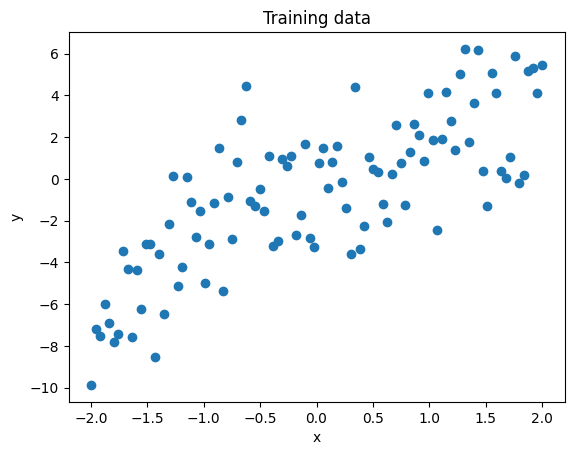

In [5]:
plot_data(xtr,ytr)

## Create polynomial features

Polynomial regression works by expanding features.
$$x\rightarrow [1,x,x^2,...,x^{deg}]$$

In [6]:
def poly_ft(x, deg):
    xp = np.ones((len(x),deg+1)) # first column = 1s
    for d in range(1,deg+1):
        xp[:,d] = x**d
    return xp

In [7]:
Xtr = poly_ft(xtr,deg)

In [8]:
Xtr[:5]

array([[ 1.        , -2.        ,  4.        , -8.        , 16.        ],
       [ 1.        , -1.95959596,  3.84001632, -7.52488047, 14.74572538],
       [ 1.        , -1.91919192,  3.68329762, -7.06895503, 13.56668138],
       [ 1.        , -1.87878788,  3.52984389, -6.63182792, 12.45979791],
       [ 1.        , -1.83838384,  3.37965514, -6.21310338, 11.42206885]])

In [9]:
Xtr.shape

(100, 5)

## Solve for optimal parameters $\theta^*$

the model is:
$$y = X\theta + \epsilon$$
where:
- $X\in\mathbb{R}^{n\times d}$
- $y\in\mathbb{R}^n$
- $\theta\in\mathbb{R}^d$

minimise the sum of squared errors: $$\min_{\theta} |y - X\theta|^2$$
expand: $$\mathcal{L}(\theta)=(y-X\theta)^T(y-X\theta)$$
$$\mathcal{L}(\theta)=y^Ty-2y^TX\theta+\theta^TX^TX\theta$$

take the gradient w.r.t. $\theta$: $$\nabla_\theta \mathcal{L} = -2X^Ty+2X^TX\theta$$

set gradient to 0 and solve for optimal $\theta$: $$\theta^* = (X^T X)^{-1} X^T y$$


the matrix $(X^T X)^{-1}$: Moore–Penrose pseudoinverse of $X$.

In [10]:
# numerically, the inverse is never computed directly
# instead solved via SVD (singular value decomposition)
theta = np.linalg.lstsq(Xtr,ytr,rcond=None)[0] # extract only the first element of return

$$y=\theta_1 x + \theta_2 x^2 + \theta_3 x^3 + \theta_4 x^4 + \theta_5$$
$$\theta \rightarrow [\theta_1, \theta_2, \theta_3, \theta_4, \theta_5]$$

In [18]:
theta

array([-0.3122924 ,  1.17411538,  0.21496914,  0.4993757 , -0.19416599])

## Analysis

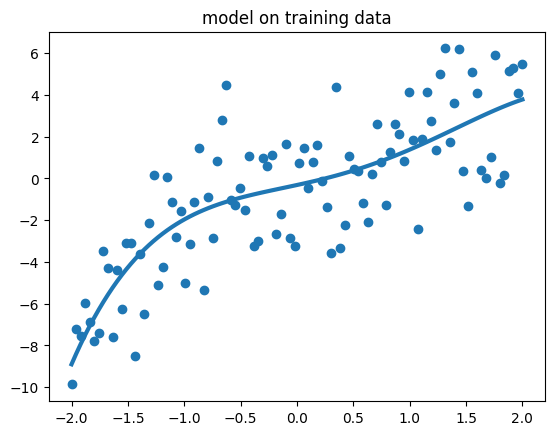

In [16]:
# predictions on training data
ytrpred = Xtr @ theta

plt.scatter(xtr, ytr)
plt.title("model on training data")
plt.plot(xtr, ytrpred, linewidth=3)
plt.show()